# Exploratory Data Analysis (EDA) – Sales Data Analysis
## Objective
Explore the sales dataset to identify trends, patterns, anomalies, and potential data quality issues using statistical analysis and visualization.



## Key Questions

- Which products generate the highest sales?
- Which region has the highest sales?
- Which category contributes the most to total sales?
- How do sales change over time?
- Are there any unusual sales values or outliers?

## 1. Dataset Overview

## 2. Data Quality Check

## 3. Statistical Summary

In [ ]:
import pandas as pd

df = pd.read_excel('/content/sale_data_Analysis.xlsx')

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Dataset Shape: (51, 8)

Column Names:
['Order ID', 'Order Date', 'Product', 'Category', 'Region', 'Quantity', 'Sales', 'Order ID.1']

Data Types:
Order ID      object
Order Date    object
Product       object
Category      object
Region        object
Quantity       int64
Sales          int64
Order ID.1    object
dtype: object


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Order ID      0
Order Date    0
Product       0
Category      0
Region        0
Quantity      0
Sales         0
Order ID.1    0
dtype: int64

Duplicate Rows:
0


In [ ]:
print(df.describe())

        Quantity          Sales
count  51.000000      51.000000
mean    2.882353   29939.215686
std     1.464883   31921.147087
min     1.000000     900.000000
25%     1.500000    7500.000000
50%     3.000000   16000.000000
75%     4.000000   40000.000000
max     5.000000  110000.000000


## 4. Sales Analysis by Product, Region and Category

In [ ]:
product_sales = df.groupby('Product')['Sales'].sum()

print(product_sales)

Product
Backpack         28600
Bookshelf        58500
Desk             48000
Headphones       52500
Laptop           90000
Mobile Phone    726000
Monitor         372000
Mouse            15300
Office Chair    136000
Name: Sales, dtype: int64


In [ ]:
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
Central    201500
East       315000
North      235500
South      466000
West       308900
Name: Sales, dtype: int64


In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Accessories      43900
Electronics    1240500
Furniture       242500
Name: Sales, dtype: int64


## 5. Regional Sales Visualization

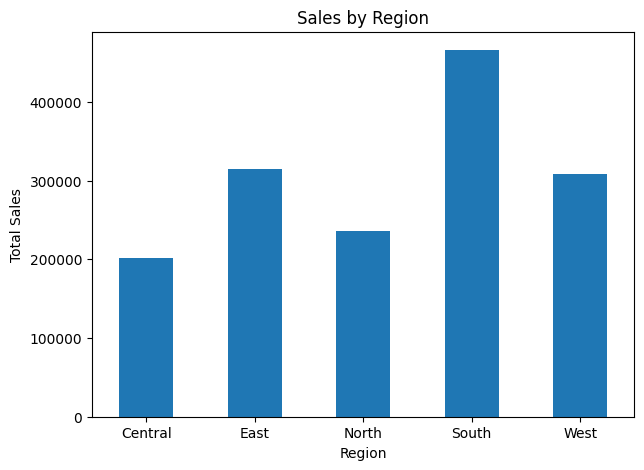

In [ ]:
import matplotlib.pyplot as plt

region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(7,5))
region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

## 6. Outlier Detection

In [ ]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]

print("Number of Sales Outliers:", len(outliers))
print(outliers)

Number of Sales Outliers: 5
   Order ID  Order Date       Product     Category Region  Quantity   Sales  \
2   ORD0003  2026-04-19  Mobile Phone  Electronics  South         5  110000   
11  ORD0012  2026-07-17        Laptop  Electronics  South         2   90000   
14  ORD0015  2026-06-12  Mobile Phone  Electronics  North         5  110000   
27  ORD0028  2026-07-12  Mobile Phone  Electronics   East         5  110000   
43  ORD0044  2026-03-02  Mobile Phone  Electronics   West         5  110000   

   Order ID.1  
2     ORD0003  
11    ORD0012  
14    ORD0015  
27    ORD0028  
43    ORD0044  


## 7. Date Preparation

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [ ]:
print(df['Order Date'].dtype)

datetime64[ns]


## 8. Sales Trend Analysis

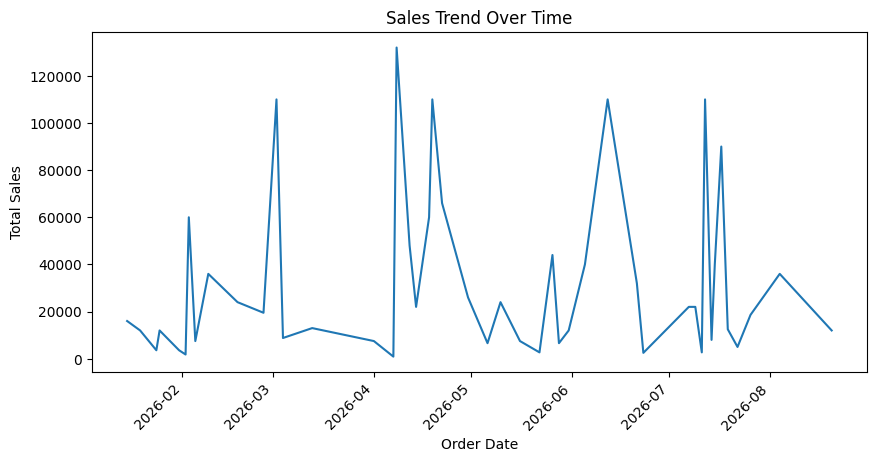

In [ ]:
sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(10,5))
sales_trend.plot(kind='line')

plt.title('Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

## 9. Outlier Visualization

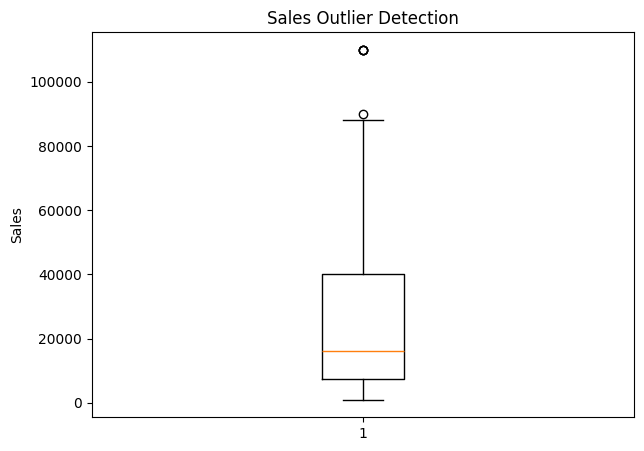

In [ ]:
plt.figure(figsize=(7,5))
plt.boxplot(df['Sales'])

plt.title('Sales Outlier Detection')
plt.ylabel('Sales')
plt.show()

## 10. Regional Average Sales Analysis

In [ ]:
average_region_sales = df.groupby('Region')['Sales'].mean()

print(average_region_sales)

Region
Central    18318.181818
East       26250.000000
North      47100.000000
South      31066.666667
West       38612.500000
Name: Sales, dtype: float64


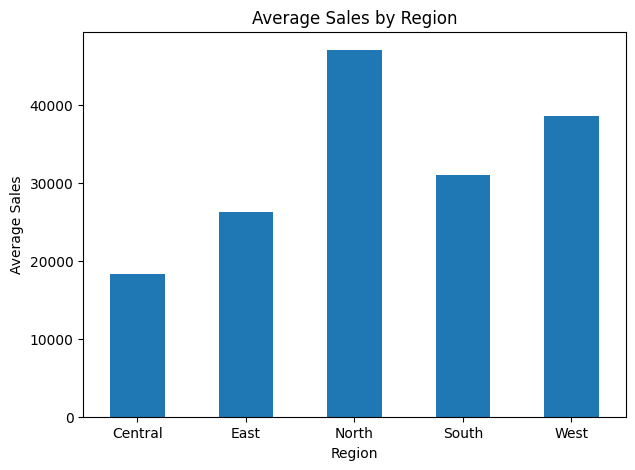

In [ ]:
average_region_sales.plot(kind='bar', figsize=(7,5))

plt.title('Average Sales by Region')
plt.xlabel('Region')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

## 11. Hypothesis Testing

In [ ]:
from scipy.stats import f_oneway

central = df[df['Region'] == 'Central']['Sales']
east = df[df['Region'] == 'East']['Sales']
north = df[df['Region'] == 'North']['Sales']
south = df[df['Region'] == 'South']['Sales']
west = df[df['Region'] == 'West']['Sales']

f_stat, p_value = f_oneway(central, east, north, south, west)

print("F-statistic:", f_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis: Average sales differ significantly across regions.")
else:
    print("Fail to reject the null hypothesis: No significant difference in average sales across regions.")

F-statistic: 0.9116513528295227
P-value: 0.46518130837385574
Fail to reject the null hypothesis: No significant difference in average sales across regions.


## 12. Final Data Quality Check

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nNegative Sales:")
print((df['Sales'] < 0).sum())

print("\nZero or Negative Quantity:")
print((df['Quantity'] <= 0).sum())

Missing Values:
Order ID      0
Order Date    0
Product       0
Category      0
Region        0
Quantity      0
Sales         0
Order ID.1    0
dtype: int64

Duplicate Rows:
0

Negative Sales:
0

Zero or Negative Quantity:
0


## Conclusion

The EDA helped identify key sales patterns, trends, and data quality issues. Overall, the analysis provided useful insights for better data-driven decisions.